# LeetCode #536: Construct Binary Tree from String

https://leetcode.com/problems/construct-binary-tree-from-string/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Stack-based parsing** | $O(n)$ | $O(n)$ |
| **Optimal: Recursive Parsing ★** | $O(n)$ | $O(n)$ |

---

## Understanding the Methods

### Stack-based parsing
Use a stack to match parentheses and attach children. Correct but requires maintaining stack state and explicit child assignment logic — more code for the same result.

### Optimal: Recursive Parsing ★
Parse the integer at the current index; if the next char is `(`, recurse for the left child and consume `)`. If another `(` follows, recurse for the right child. The call stack naturally models the tree structure.

**Why this is better than Stack-based:** The recursion mirrors the grammar of the format exactly — no auxiliary stack to manage, and the code is shorter and clearer.

**Constraints:**
* $0 \le$ Node.val $\le 10^4$ — but note negative values appear in examples; handle sign.
* The string length is in $[0, 3 \times 10^4]$.

## Solutions

### C#

In [ ]:
public TreeNode Str2tree(string s) {
    int idx = 0;
    TreeNode Parse() {
        if (idx >= s.Length) return null;
        // Parse optional minus sign
        int sign = 1;
        if (s[idx] == '-') { sign = -1; idx++; }
        // Parse integer digits
        int num = 0;
        while (idx < s.Length && char.IsDigit(s[idx]))
            num = num * 10 + (s[idx++] - '0');
        var node = new TreeNode(sign * num);
        // Left child follows if '(' is next
        if (idx < s.Length && s[idx] == '(') { idx++; node.left  = Parse(); idx++; }
        // Right child follows if another '(' is next
        if (idx < s.Length && s[idx] == '(') { idx++; node.right = Parse(); idx++; }
        return node;
    }
    return string.IsNullOrEmpty(s) ? null : Parse();
}

### Python

In [ ]:
def str2tree(self, s: str) -> Optional[TreeNode]:
    if not s:
        return None
    self.idx = 0

    def parse():
        # Parse optional minus sign
        sign = 1
        if self.idx < len(s) and s[self.idx] == '-':
            sign = -1; self.idx += 1
        # Parse integer digits
        num = 0
        while self.idx < len(s) and s[self.idx].isdigit():
            num = num * 10 + int(s[self.idx]); self.idx += 1
        node = TreeNode(sign * num)
        # Left child follows if '(' is next
        if self.idx < len(s) and s[self.idx] == '(':
            self.idx += 1; node.left = parse(); self.idx += 1
        # Right child follows if another '(' is next
        if self.idx < len(s) and s[self.idx] == '(':
            self.idx += 1; node.right = parse(); self.idx += 1
        return node

    return parse()

### Go

In [ ]:
func str2tree(s string) *TreeNode {
    if s == "" { return nil }
    idx := 0
    var parse func() *TreeNode
    parse = func() *TreeNode {
        // Parse optional minus sign
        sign := 1
        if idx < len(s) && s[idx] == '-' { sign = -1; idx++ }
        // Parse integer digits
        num := 0
        for idx < len(s) && s[idx] >= '0' && s[idx] <= '9' {
            num = num*10 + int(s[idx]-'0'); idx++
        }
        node := &TreeNode{Val: sign * num}
        // Left child follows if '(' is next
        if idx < len(s) && s[idx] == '(' { idx++; node.Left = parse(); idx++ }
        // Right child follows if another '(' is next
        if idx < len(s) && s[idx] == '(' { idx++; node.Right = parse(); idx++ }
        return node
    }
    return parse()
}

### Rust

In [ ]:
pub fn str2tree(s: String) -> Option<Rc<RefCell<TreeNode>>> {
    let bytes = s.as_bytes();
    let mut idx = 0usize;
    fn parse(b: &[u8], idx: &mut usize) -> Option<Rc<RefCell<TreeNode>>> {
        if *idx >= b.len() { return None; }
        // Parse optional minus sign
        let sign: i32 = if b[*idx] == b'-' { *idx += 1; -1 } else { 1 };
        // Parse integer digits
        let mut num = 0i32;
        while *idx < b.len() && b[*idx].is_ascii_digit() {
            num = num * 10 + (b[*idx] - b'0') as i32; *idx += 1;
        }
        let node = Rc::new(RefCell::new(TreeNode::new(sign * num)));
        // Left child follows if '(' is next
        if *idx < b.len() && b[*idx] == b'(' {
            *idx += 1;
            node.borrow_mut().left = parse(b, idx);
            *idx += 1;
        }
        // Right child follows if another '(' is next
        if *idx < b.len() && b[*idx] == b'(' {
            *idx += 1;
            node.borrow_mut().right = parse(b, idx);
            *idx += 1;
        }
        Some(node)
    }
    if s.is_empty() { return None; }
    parse(bytes, &mut idx)
}

## Example Scenarios

**1. Common Case**
**Input:** s = "4(2(3)(1))(6(5))"
Parse 4 → left child: parse 2 → left: parse 3 (no parens, leaf), right: parse 1 (leaf). Back at 4, right child: parse 6 → left: parse 5 (leaf), no right. Tree: 4 with children 2 and 6.

**2. Slightly Complex**
**Input:** s = "1(-2(3))"
Sign detection: '-' at position 2 gives node.val=-2. Left child parsed as 3. No second '(' so no right child. Root=1, left=-2, left-left=3.

**3. Edge Case: Time Factor**
**Input:** s with $3 \times 10^4$ characters representing a deep left-skewed tree "1(2(3(4(...))))"
The recursive parser's call stack depth equals the tree height $\approx n$. Each character is processed exactly once, so time is $O(n)$, but stack space is $O(n)$ — worst case for recursion depth.

**4. Edge Case: Space Factor**
**Input:** s = "0(1)(2)(3)..." — wide tree with many children at depth 1
Each child is parsed as a separate recursive call that returns immediately (leaves). Stack depth stays $O(1)$, but the output tree has $O(n)$ nodes. Space dominated by the output, not the stack.

**5. Almost-Impossible but Plausible**
**Input:** s = "-9999(9999)(-9999)"
Two consecutive negative values requiring sign handling at depth 1. Parser reads '-' then digits for each child. Tests that the sign flag resets correctly between recursive calls — a common off-by-one mistake.

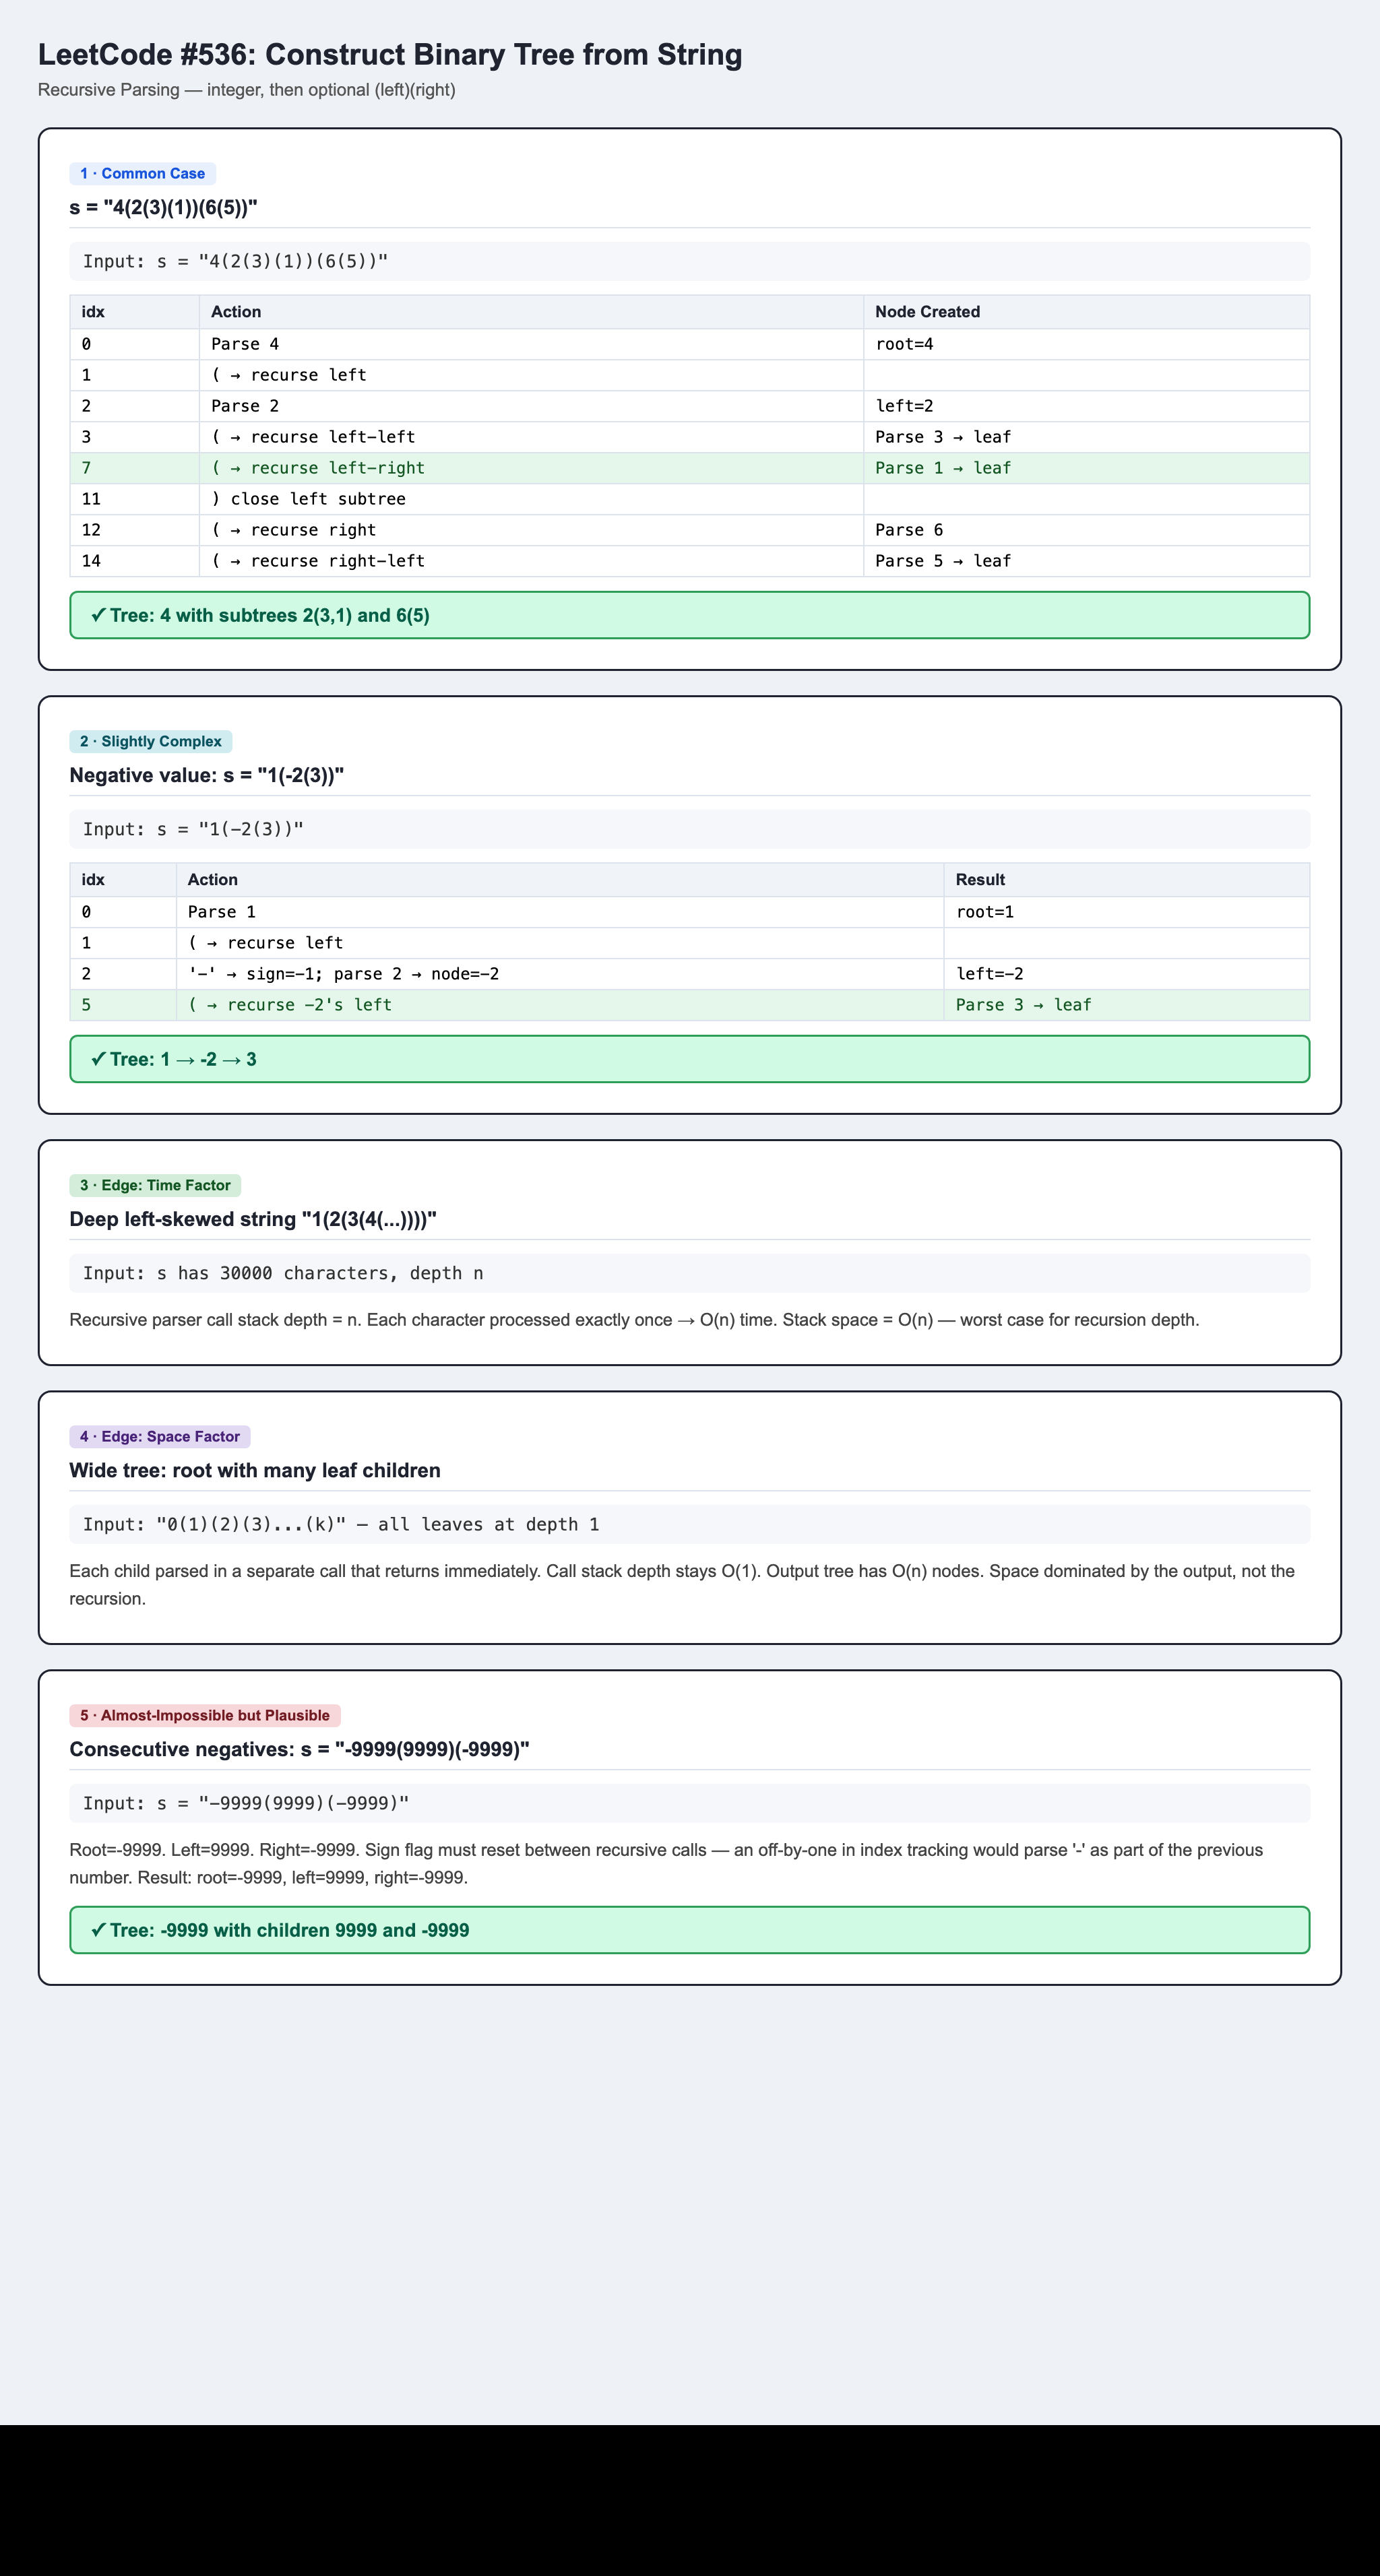